In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

Hamiltonian in rotating frame of a three-level-system driven with Rabi frequency $\Omega$ and detuning $\delta$ between levels 0 and 1.
The frequency difference between level 1 and 2 is $d=\omega_2 - \omega_1$.

$$
H = \begin{pmatrix}
    0 & -\Omega/2 & -\Omega/2 \\
    -\Omega/2 & -\delta & 0 \\
    -\Omega/2 & 0 & -\delta + d\\
\end{pmatrix}
$$

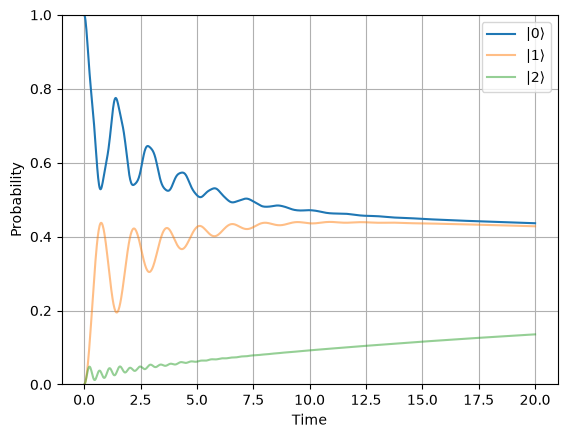

In [ ]:
omega = 3          # Rabi frequency
delta = -3         # detuning between |0> and |1>
d = 10             # frequency difference between |1> and |2>
gamma = 0.01       # decay rate
gamma_phi = 0.2    # dephasing rate (typically >>gamma)

H = qt.Qobj([[0, -omega/2, -omega/2],
            [-omega/2, -delta, 0],
            [-omega/2, 0, -delta+d]])

# initial state |0>
rho0 = qt.ket2dm(qt.basis(3,0))

# projectors onto states |0>, |1>, |2> for population measurement
proj0 = qt.ket2dm(qt.basis(3,0))
proj1 = qt.ket2dm(qt.basis(3,1))
proj2 = qt.ket2dm(qt.basis(3,2))

# lindblad jump operators for decay and dephasing
decay_1 = np.sqrt(gamma) * qt.basis(3,0) * qt.basis(3,1).dag()
decay_2 = np.sqrt(gamma) * qt.basis(3,0) * qt.basis(3,2).dag()
dephase_01 = np.sqrt(gamma_phi) * qt.Qobj(np.diag([1, -1, 0]))
dephase_02 = np.sqrt(gamma_phi) * qt.Qobj(np.diag([1, 0, -1]))
dephase_12 = np.sqrt(gamma_phi) * qt.Qobj(np.diag([0, 1, -1]))

# simulate for times ts
ts = np.linspace(0, 20, 1000)
sim = qt.mesolve(H, rho0, ts, c_ops=[decay_1, decay_2, dephase_01, dephase_02, dephase_12],
                 e_ops=[proj0, proj1, proj2])

# plot
fig, ax = plt.subplots()
ax.plot(ts, sim.expect[0], label=r"$|0\rangle$")
ax.plot(ts, sim.expect[1], alpha=0.5, label=r"$|1\rangle$")
ax.plot(ts, sim.expect[2], alpha=0.5, label=r"$|2\rangle$")
ax.set(xlabel="Time", ylabel="Probability", ylim=(0,1))
ax.grid()
ax.legend()

In [90]:
from ipywidgets import interact

def interactive_plot(omega, delta, d, gamma, gamma_phi):

    H = qt.Qobj([[0, -omega/2, -omega/2],
                [-omega/2, -delta, 0],
                [-omega/2, 0, -delta+d]])

    rho0 = qt.ket2dm(qt.basis(3,0))
    proj0 = qt.ket2dm(qt.basis(3,0))
    proj1 = qt.ket2dm(qt.basis(3,1))
    proj2 = qt.ket2dm(qt.basis(3,2))
    decay_1 = np.sqrt(gamma) * qt.basis(3,0) * qt.basis(3,1).dag()
    decay_2 = np.sqrt(gamma) * qt.basis(3,0) * qt.basis(3,2).dag()
    dephase_01 = np.sqrt(gamma_phi) * qt.Qobj(np.diag([1, -1, 0]))
    dephase_02 = np.sqrt(gamma_phi) * qt.Qobj(np.diag([1, 0, -1]))
    dephase_12 = np.sqrt(gamma_phi) * qt.Qobj(np.diag([0, 1, -1]))

    ts = np.linspace(0, 20, 1000)
    sim = qt.mesolve(H, rho0, ts, c_ops=[decay_1, decay_2, dephase_01, dephase_02, dephase_12],
                     e_ops=[proj0, proj1, proj2])

    fig, ax = plt.subplots()
    ax.plot(ts, sim.expect[0], label=r"$|0\rangle$")
    ax.plot(ts, sim.expect[1], alpha=0.5, label=r"$|1\rangle$")
    ax.plot(ts, sim.expect[2], alpha=0.5, label=r"$|2\rangle$")
    ax.set(xlabel="Time", ylabel="Probability", ylim=(0,1))
    ax.grid()
    ax.legend()


interact(interactive_plot, omega=(0, 10, 0.1), delta=(-5, 5, 0.1), d=(0, 100, 0.1), gamma=(0, 0.1, 0.001), gamma_phi=(0, 1, 0.01))

interactive(children=(FloatSlider(value=5.0, description='omega', max=10.0), FloatSlider(value=0.0, descriptio…

<function __main__.interactive_plot(omega, delta, d, gamma, gamma_phi)>